In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("  Case Study 2: CNN Image Classification — CIFAR-10")
print("=" * 55)

  Case Study 2: CNN Image Classification — CIFAR-10


In [2]:
# ── 1. Load & Preprocess ──────────────────────────────
print("\n[1/5] Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"    Train : {x_train.shape[0]} images  {x_train.shape[1:]}")
print(f"    Test  : {x_test.shape[0]}  images  {x_test.shape[1:]}")
print(f"    Classes: {class_names}")



[1/5] Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
    Train : 50000 images  (32, 32, 3)
    Test  : 10000  images  (32, 32, 3)
    Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



[2/5] Plotting sample images...


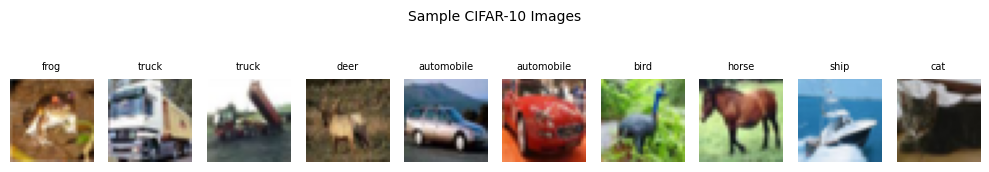

In [3]:
# ── 2. Visualise Sample Images ────────────────────────
print("\n[2/5] Plotting sample images...")
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=10)
plt.tight_layout()
plt.show()

In [4]:
# ── 3. Build CNN Model ────────────────────────────────
# Architecture:
#   Block 1 : Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
#   Block 2 : Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
#   Block 3 : Conv(128)→ BN → ReLU → MaxPool → Dropout(0.25)
#   Head    : Flatten → Dense(512) → BN → ReLU → Dropout(0.5) → Output(10, Softmax)

print("\n[3/5] Building CNN model...")

model = models.Sequential([

    # ── Block 1 ──
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ── Block 2 ──
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ── Block 3 ──
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ── Fully Connected Head ──
    layers.Flatten(),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()


[3/5] Building CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,196,970 (4.57 MB)

 Trainable params: 1,195,306 (4.56 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [5]:

# ── 4. Compile ────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# ── 5. Data Augmentation ──────────────────────────────
# Helps prevent overfitting by randomly transforming training images
print("\n[4/5] Setting up data augmentation + training...")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

# Wrap into augmented dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (train_dataset
                 .shuffle(50000)
                 .batch(64)
                 .map(lambda x, y: (data_augmentation(x, training=True), y),
                      num_parallel_calls=tf.data.AUTOTUNE)
                 .prefetch(tf.data.AUTOTUNE))

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset  = test_dataset.batch(64).prefetch(tf.data.AUTOTUNE)


[4/5] Setting up data augmentation + training...


In [7]:
# ── 6. Callbacks ──────────────────────────────────────
cb_list = [
    # Reduce LR by 0.5 if val_loss doesn't improve for 3 epochs
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1, min_lr=1e-6),
    # Stop early if val_loss doesn't improve for 8 epochs
    callbacks.EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1)
]

In [8]:

# ── 7. Train ──────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=test_dataset,
    callbacks=cb_list
)


Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.3882 - loss: 1.7366 - val_accuracy: 0.4378 - val_loss: 1.6467 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5119 - loss: 1.3617 - val_accuracy: 0.5055 - val_loss: 1.4059 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5593 - loss: 1.2293 - val_accuracy: 0.5789 - val_loss: 1.2145 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5994 - loss: 1.1271 - val_accuracy: 0.5462 - val_loss: 1.4424 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6166 - loss: 1.0730 - val_accuracy: 0.5480 - val_loss: 1.3994 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6348 - loss: 1.0322 - val_accuracy: 0.6160 - val_loss: 1.1771 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6530 - l

In [9]:
# ── 8. Evaluate ───────────────────────────────────────
print("\n[5/5] Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"\n{'='*55}")
print(f"  ✅  Test Accuracy : {test_acc*100:.2f}%")
print(f"  📉  Test Loss     : {test_loss:.4f}")
print(f"{'='*55}")



[5/5] Evaluating on test set...

  ✅  Test Accuracy : 79.77%
  📉  Test Loss     : 0.5843


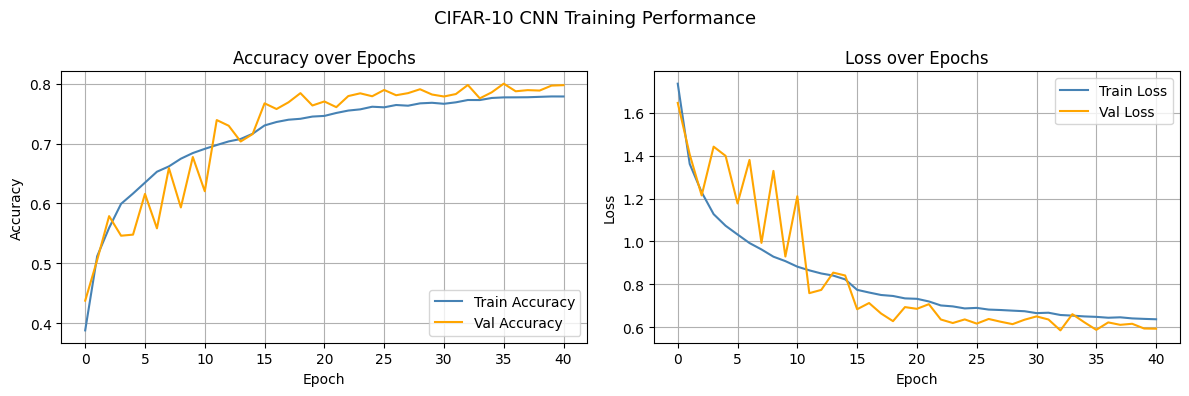

In [10]:
# ── 9. Plot Training Curves ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.suptitle('CIFAR-10 CNN Training Performance', fontsize=13)
plt.tight_layout()
plt.show()



Per-class accuracy:
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
    airplane    :  81.8%  ████████████████
    automobile  :  91.4%  ██████████████████
    bird        :  66.3%  █████████████
    cat         :  60.7%  ████████████
    deer        :  69.6%  █████████████
    dog         :  67.5%  █████████████
    frog        :  94.0%  ██████████████████
    horse       :  83.7%  ████████████████
    ship        :  89.8%  █████████████████
    truck       :  92.9%  ██████████████████


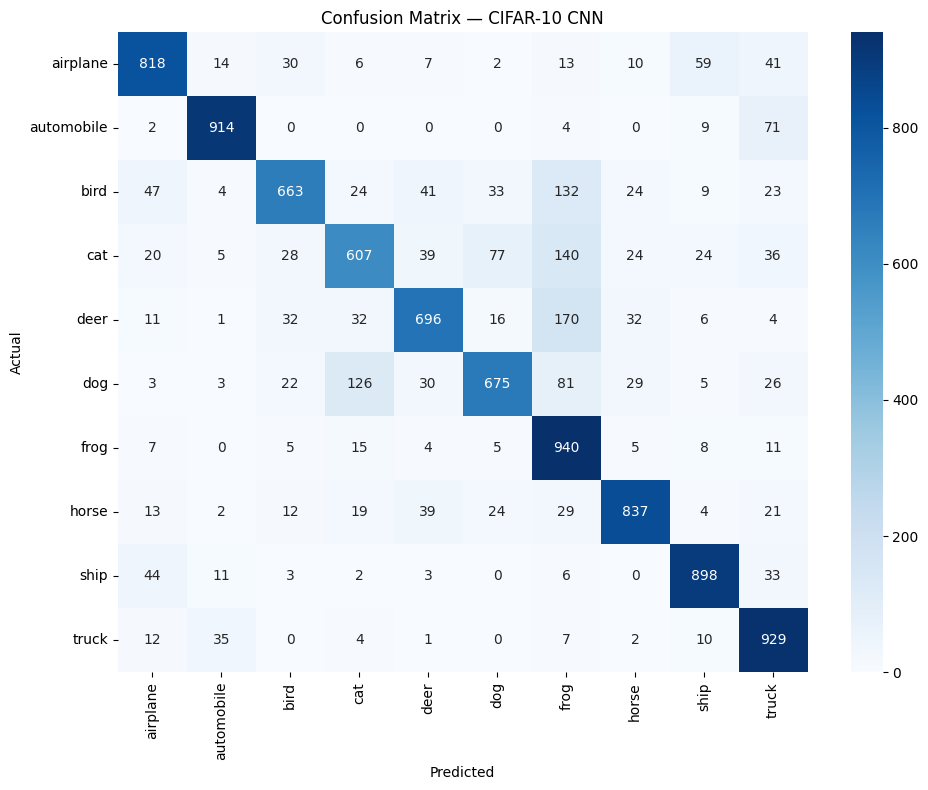

In [11]:
# ── 10. Per-class Accuracy ────────────────────────────
print("\nPer-class accuracy:")
y_pred   = np.argmax(model.predict(test_dataset), axis=1)
y_true   = y_test.flatten()

for i, name in enumerate(class_names):
    mask = y_true == i
    acc  = np.mean(y_pred[mask] == i)
    bar  = "█" * int(acc * 20)
    print(f"    {name:<12}: {acc*100:5.1f}%  {bar}")

# ── 11. Confusion Matrix ──────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — CIFAR-10 CNN')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()